In [2]:
%pip install -q -U \
    "langchain>=0.3.0" \
    "langchain-community>=0.3.0" \
    "langchain-chroma>=0.1.4" \
    "langchain-huggingface>=0.1.0" \
    "chromadb>=0.5.0" \
    "sentence-transformers>=3.0.0" \
    "huggingface-hub>=0.25.0" \
    "anthropic>=0.40.0" \
    "pandas" "numpy" "matplotlib" "joblib"

print(' Packages installed/upgraded. If this is the FIRST time running this cell, '
      'restart the kernel now (Kernel > Restart Kernel) before running the next cells.')

 Packages installed/upgraded. If this is the FIRST time running this cell, restart the kernel now (Kernel > Restart Kernel) before running the next cells.


In [2]:
import os, re, time, json, textwrap
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
!pip install -U langchain langchain-text-splitters langchain-community numpy scipy nltk

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

print('Libraries loaded')

Libraries loaded


In [3]:
import numpy as np
print(f"NumPy version: {np.__version__}")

NumPy version: 2.5.0


In [4]:

FINANCIAL_DOCUMENTS = [
    {
        'title':  'Apple Q4 2024 Earnings Report',
        'date':   '2024-11-01',
        'ticker': 'AAPL',
        'text':   """
Apple Inc. reported fourth-quarter fiscal 2024 results with revenue of $94.9 billion,
up 6% year-over-year, beating analyst estimates of $94.5 billion. iPhone revenue rose
5.5% to $46.2 billion, driven by strong iPhone 16 demand. Services revenue reached a
record $24.2 billion, up 12% YoY. CEO Tim Cook highlighted AI integration across the
product lineup as a key growth driver. EPS of $1.64 beat the consensus estimate of $1.60.
Apple returned $29 billion to shareholders through dividends and buybacks.
Gross margin expanded to 46.2%, exceeding guidance of 45.5–46.5%.
India revenue grew 20% YoY, marking Apple's fastest-growing major market.
"""
    },
    {
        'title':  'Federal Reserve Interest Rate Decision November 2024',
        'date':   '2024-11-07',
        'ticker': 'MARKET',
        'text':   """
The Federal Reserve cut interest rates by 25 basis points at its November 2024 meeting,
bringing the federal funds rate to 4.5-4.75%. Fed Chair Jerome Powell stated the decision
reflects growing confidence that inflation is moving toward the 2% target. The S&P 500
rallied 2.5% following the announcement. Treasury yields fell sharply, with the 10-year
yield dropping 12 basis points to 4.28%. Markets are now pricing in two additional
25 bps cuts in 2025. The decision was unanimous among FOMC members. Powell emphasized
that future rate decisions remain data-dependent, particularly on employment and inflation.
"""
    },
    {
        'title':  'Apple AI Strategy & iPhone 16 Analysis',
        'date':   '2024-10-15',
        'ticker': 'AAPL',
        'text':   """
Apple Intelligence, the company's AI platform, rolled out with iOS 18.1 and represents
the biggest iPhone software update in years. Key features include a revamped Siri with
LLM capabilities, AI-powered writing tools, photo editing, and priority notification
management. Analysts at Goldman Sachs believe Apple Intelligence could drive an
upgrade supercycle, potentially adding $30-40 billion in incremental iPhone revenue.
The iPhone 16 lineup benefits from a dedicated Neural Engine chip processing 35 TOPS.
Apple's on-device processing approach differentiates it from cloud-dependent competitors,
positioning it well for enterprise privacy-conscious deployments.
"""
    },
    {
        'title':  'Tech Sector Market Outlook 2025',
        'date':   '2024-12-01',
        'ticker': 'TECH',
        'text':   """
Technology sector analysts forecast continued outperformance in 2025 driven by AI
infrastructure spending, with hyperscalers expected to invest over $300 billion in
capital expenditure. Microsoft Azure, AWS, and Google Cloud are projected to see
accelerating growth as enterprise AI adoption moves from pilot to production.
Semiconductor stocks, particularly NVIDIA, AMD, and TSMC suppliers, are positioned
for strong demand from AI training workloads. Risks include potential regulation of
large language models, antitrust scrutiny of big tech, and macroeconomic headwinds
from persistent inflation. The Philadelphia Semiconductor Index (SOX) is expected
to outperform the broader market by 15-20% based on earnings growth projections.
"""
    },
    {
        'title':  'Apple Supply Chain & China Risk Analysis',
        'date':   '2024-09-20',
        'ticker': 'AAPL',
        'text':   """
Apple's supply chain diversification accelerated in 2024, with India now manufacturing
approximately 14% of global iPhone units, up from 7% in 2023. Foxconn and Tata
Electronics are expanding Indian production capacity significantly. China remains
Apple's largest manufacturing hub at ~80% of production but geopolitical risks
have prompted the company to accelerate the India-plus strategy. Vietnam production
of AirPods and Apple Watch components reached 60% of global supply. Analysts
estimate that supply chain diversification adds approximately $2-3 in annual EPS
protection against China tariff risks.
"""
    },
    {
        'title':  'RSI and Technical Analysis Fundamentals',
        'date':   '2024-01-01',
        'ticker': 'EDUCATION',
        'text':   """
The Relative Strength Index (RSI) is a momentum oscillator measuring speed and change of
price movements on a scale of 0–100. RSI above 70 indicates overbought conditions and
potential reversal. RSI below 30 signals oversold conditions and possible bounce.
The MACD (Moving Average Convergence Divergence) uses 12-day and 26-day EMAs; a bullish
signal occurs when the MACD line crosses above its 9-day signal line. Bollinger Bands
set upper and lower bounds 2 standard deviations from a 20-day SMA; price touching
the upper band often signals overbought conditions. Support and resistance levels
are price points where buying or selling pressure has historically reversed trends.
Volume confirms trend strength: rising prices with rising volume confirm an uptrend.
"""
    },
]

print(f' Knowledge base: {len(FINANCIAL_DOCUMENTS)} documents loaded')

 Knowledge base: 6 documents loaded


In [8]:
print(' Loading embedding model (this may take 1-2 min first run)...')
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'}
)

langchain_documents = []
for doc in FINANCIAL_DOCUMENTS:
    langchain_documents.append(Document(page_content=doc['text'], metadata={'source': doc['title'], 'date': doc['date'], 'ticker': doc['ticker']}))

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, add_start_index=True
)

chunks = text_splitter.split_documents(langchain_documents)
print(f' Split into {len(chunks)} chunks')

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory='./chroma_stock_db',
    collection_name='stock_knowledge'
)
print(f' Vector store built with {vectorstore._collection.count()} vectors')

 Loading embedding model (this may take 1-2 min first run)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 Split into 6 chunks
 Vector store built with 6 vectors


In [10]:
class StockRAGRetriever:
    def __init__(self, vectorstore, k: int = 3):
        self.retriever = vectorstore.as_retriever(
            search_type='mmr',
            search_kwargs={'k': k, 'fetch_k': k * 3}
        )

    def retrieve(self, query: str) -> tuple[list[Document], str]:
        docs = self.retriever.invoke(query)
        context = self._format_context(docs)
        return docs, context

    @staticmethod
    def _format_context(docs: list[Document]) -> str:
        parts = []
        for i, d in enumerate(docs, 1):
            m = d.metadata
            parts.append(
                f"[Source {i}] {m.get('source','Unknown')} | {m.get('date','N/A')}\n"
                f"{d.page_content.strip()}"
            )
        return '\n\n'.join(parts)


retriever = StockRAGRetriever(vectorstore, k=3)

test_q = 'What is the outlook for Apple stock performance?'
docs, context = retriever.retrieve(test_q)
print(f'Query: "{test_q}"')
print(f'Retrieved {len(docs)} documents:\n')
for d in docs:
    print(f'   {d.metadata["source"]} ({d.metadata["date"]})')
print('\nContext preview (first 400 chars):')
print(context[:400], '...')

Query: "What is the outlook for Apple stock performance?"
Retrieved 3 documents:

   Apple Q4 2024 Earnings Report (2024-11-01)
   RSI and Technical Analysis Fundamentals (2024-01-01)
   Federal Reserve Interest Rate Decision November 2024 (2024-11-07)

Context preview (first 400 chars):
[Source 1] Apple Q4 2024 Earnings Report | 2024-11-01
Apple Inc. reported fourth-quarter fiscal 2024 results with revenue of $94.9 billion,
up 6% year-over-year, beating analyst estimates of $94.5 billion. iPhone revenue rose
5.5% to $46.2 billion, driven by strong iPhone 16 demand. Services revenue reached a
record $24.2 billion, up 12% YoY. CEO Tim Cook highlighted AI integration across the
prod ...


In [12]:
import anthropic

LLM_CLIENT = None
try:
    LLM_CLIENT = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY', ''))
    print(' Anthropic client initialised')
except Exception as e:
    print(f'  LLM not available: {e}\n   Set ANTHROPIC_API_KEY to enable real LLM responses.')


SYSTEM_PROMPT = """
You are FinanceGPT, an expert stock market analyst and financial advisor AI.
You answer questions using the provided context from financial news and reports.
Always:
- Ground your answer in the retrieved context
- Cite sources explicitly (e.g. [Source 1])
- Quantify insights with specific numbers when available
- Note any limitations or risks
- End with a clear, actionable summary
- NEVER make up data not in the context
""".strip()


def llm_generate(query: str, context: str,
                 ml_signal: dict = None) -> str:
    """Generate a grounded LLM response."""

    signal_block = ''
    if ml_signal:
        signal_block = f"""
ML Model Signal (from our trained classifier):
  • Prediction:   {'📈 BUY (Bullish)' if ml_signal['pred']==1 else '📉 SELL (Bearish)'}
  • Confidence:   {ml_signal['conf']*100:.1f}%
  • Key indicator: RSI={ml_signal.get('rsi',50):.1f}, MACD={ml_signal.get('macd',0):.3f}
"""

    user_message = f"""
RETRIEVED CONTEXT:
{context}

{signal_block}
USER QUESTION: {query}

Please provide a comprehensive analysis based on the context above.
""".strip()

    if LLM_CLIENT and os.environ.get('ANTHROPIC_API_KEY', ''):
        response = LLM_CLIENT.messages.create(
            model='claude-haiku-4-5-20251001',
            max_tokens=1024,
            system=SYSTEM_PROMPT,
            messages=[{'role': 'user', 'content': user_message}]
        )
        return response.content[0].text
    else:

        return (
            f'[Demo Mode – no API key]\n\n'
            f'Based on the retrieved context:\n\n'
            f'{context[:600]}...\n\n'
            f'To get a full LLM-generated analysis, set your ANTHROPIC_API_KEY.'
        )

print('LLM function ready')

 Anthropic client initialised
LLM function ready


In [15]:
import joblib

def get_latest_ml_signal(ticker='AAPL'):

    try:
        df_feat = pd.read_csv('stock_features.csv', index_col=0, parse_dates=True)
        ensemble = joblib.load('ensemble_model.pkl')
        scaler   = joblib.load('scaler.pkl')

        FEATURES = [
            'SMA_7','SMA_21','EMA_21','BB_Width','RSI',
            'MACD','MACD_Signal','MACD_Hist','ATR','Volume_Ratio',
            'Return_1d','Return_5d','Return_21d','Lag_1','Lag_2','Lag_3','Lag_5'
        ]
        latest = df_feat[FEATURES].iloc[[-1]]
        latest_sc = scaler.transform(latest)

        pred  = ensemble.predict(latest_sc)[0]
        proba = ensemble.predict_proba(latest_sc)[0][1]
        rsi   = df_feat['RSI'].iloc[-1]
        macd  = df_feat['MACD'].iloc[-1]

        return {'pred': int(pred), 'conf': float(max(proba, 1-proba)),
                'rsi': float(rsi), 'macd': float(macd)}
    except Exception as e:
        print(f'  ML signal unavailable ({e}), using dummy signal')
        return {'pred': 1, 'conf': 0.65, 'rsi': 55.0, 'macd': 0.12}


class FinanceRAGPipeline:


    def __init__(self, retriever: StockRAGRetriever, ticker: str = 'AAPL'):
        self.retriever = retriever
        self.ticker    = ticker
        self.history   = []

    def query(self, question: str, use_ml_signal: bool = True,
              verbose: bool = True) -> str:
        sep = '=' * 60
        print(f'\n{sep}')
        print(f' Question: {question}')
        print(sep)


        docs, context = self.retriever.retrieve(question)
        if verbose:
            print(f'\n Retrieved {len(docs)} chunks:')
            for d in docs:
                print(f'    {d.metadata["source"]} ({d.metadata["date"]})')


        signal = get_latest_ml_signal(self.ticker) if use_ml_signal else None
        if verbose and signal:
            label = "BUY" if signal["pred"] == 1 else "SELL"
            print(f'\n ML Signal: {label} (conf: {signal["conf"]*100:.1f}%)')

        print('\n Generating LLM response...')
        answer = llm_generate(question, context, signal)

        self.history.append({'q': question, 'a': answer,
                             'sources': [d.metadata['source'] for d in docs]})

        print(f'\n Answer:\n{answer}')
        return answer


pipeline = FinanceRAGPipeline(retriever, ticker='AAPL')
print(' RAG Pipeline ready')

 RAG Pipeline ready


In [16]:

_ = pipeline.query('What were Apple\'s latest earnings highlights and key growth drivers?')


 Question: What were Apple's latest earnings highlights and key growth drivers?

 Retrieved 3 chunks:
    Apple Q4 2024 Earnings Report (2024-11-01)
    RSI and Technical Analysis Fundamentals (2024-01-01)
    Federal Reserve Interest Rate Decision November 2024 (2024-11-07)
  ML signal unavailable ([Errno 2] No such file or directory: 'stock_features.csv'), using dummy signal

 ML Signal: BUY (conf: 65.0%)

 Generating LLM response...

 Answer:
[Demo Mode – no API key]

Based on the retrieved context:

[Source 1] Apple Q4 2024 Earnings Report | 2024-11-01
Apple Inc. reported fourth-quarter fiscal 2024 results with revenue of $94.9 billion,
up 6% year-over-year, beating analyst estimates of $94.5 billion. iPhone revenue rose
5.5% to $46.2 billion, driven by strong iPhone 16 demand. Services revenue reached a
record $24.2 billion, up 12% YoY. CEO Tim Cook highlighted AI integration across the
product lineup as a key growth driver. EPS of $1.64 beat the consensus estimate of $1.60.
Appl

In [17]:

_ = pipeline.query('What were Apple\'s latest earnings highlights and key growth drivers?')


 Question: What were Apple's latest earnings highlights and key growth drivers?

 Retrieved 3 chunks:
    Apple Q4 2024 Earnings Report (2024-11-01)
    RSI and Technical Analysis Fundamentals (2024-01-01)
    Federal Reserve Interest Rate Decision November 2024 (2024-11-07)
  ML signal unavailable ([Errno 2] No such file or directory: 'stock_features.csv'), using dummy signal

 ML Signal: BUY (conf: 65.0%)

 Generating LLM response...

 Answer:
[Demo Mode – no API key]

Based on the retrieved context:

[Source 1] Apple Q4 2024 Earnings Report | 2024-11-01
Apple Inc. reported fourth-quarter fiscal 2024 results with revenue of $94.9 billion,
up 6% year-over-year, beating analyst estimates of $94.5 billion. iPhone revenue rose
5.5% to $46.2 billion, driven by strong iPhone 16 demand. Services revenue reached a
record $24.2 billion, up 12% YoY. CEO Tim Cook highlighted AI integration across the
product lineup as a key growth driver. EPS of $1.64 beat the consensus estimate of $1.60.
Appl

In [18]:
_ = pipeline.query('What are the key risks for Apple related to China and supply chain?')


 Question: What are the key risks for Apple related to China and supply chain?

 Retrieved 3 chunks:
    Apple Supply Chain & China Risk Analysis (2024-09-20)
    Apple AI Strategy & iPhone 16 Analysis (2024-10-15)
    RSI and Technical Analysis Fundamentals (2024-01-01)
  ML signal unavailable ([Errno 2] No such file or directory: 'stock_features.csv'), using dummy signal

 ML Signal: BUY (conf: 65.0%)

 Generating LLM response...

 Answer:
[Demo Mode – no API key]

Based on the retrieved context:

[Source 1] Apple Supply Chain & China Risk Analysis | 2024-09-20
Apple's supply chain diversification accelerated in 2024, with India now manufacturing
approximately 14% of global iPhone units, up from 7% in 2023. Foxconn and Tata
Electronics are expanding Indian production capacity significantly. China remains
Apple's largest manufacturing hub at ~80% of production but geopolitical risks
have prompted the company to accelerate the India-plus strategy. Vietnam production
of AirPods and App

In [19]:
_ = pipeline.query('Explain what RSI and MACD signals mean for stock trading decisions.')


 Question: Explain what RSI and MACD signals mean for stock trading decisions.

 Retrieved 3 chunks:
    RSI and Technical Analysis Fundamentals (2024-01-01)
    Federal Reserve Interest Rate Decision November 2024 (2024-11-07)
    Apple AI Strategy & iPhone 16 Analysis (2024-10-15)
  ML signal unavailable ([Errno 2] No such file or directory: 'stock_features.csv'), using dummy signal

 ML Signal: BUY (conf: 65.0%)

 Generating LLM response...

 Answer:
[Demo Mode – no API key]

Based on the retrieved context:

[Source 1] RSI and Technical Analysis Fundamentals | 2024-01-01
The Relative Strength Index (RSI) is a momentum oscillator measuring speed and change of
price movements on a scale of 0–100. RSI above 70 indicates overbought conditions and
potential reversal. RSI below 30 signals oversold conditions and possible bounce.
The MACD (Moving Average Convergence Divergence) uses 12-day and 26-day EMAs; a bullish
signal occurs when the MACD line crosses above its 9-day signal line. Bol


 Retrieval Evaluation:
                         Query  Expected  Hit
          Apple revenue growth      AAPL True
Federal Reserve interest rates    MARKET True
 AI chips semiconductor market      TECH True
         RSI overbought signal EDUCATION True
      iPhone 16 sales forecast      AAPL True

Precision@3: 1.00 (100%)


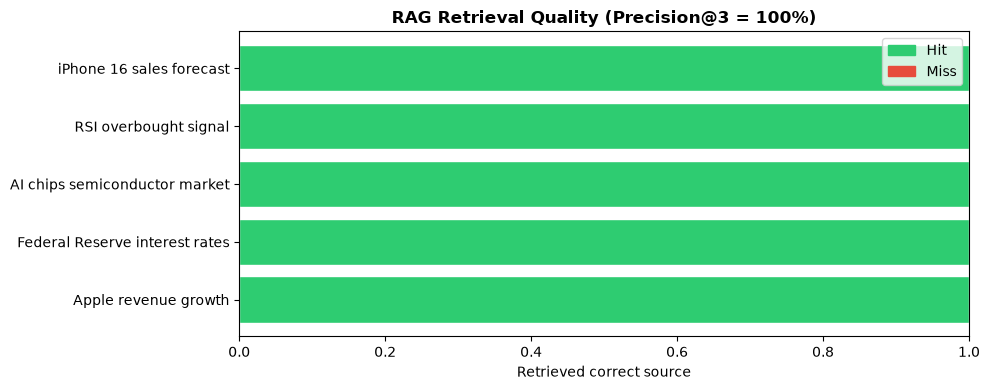

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

eval_queries = [
    ('Apple revenue growth',          'AAPL'),
    ('Federal Reserve interest rates','MARKET'),
    ('AI chips semiconductor market', 'TECH'),
    ('RSI overbought signal',         'EDUCATION'),
    ('iPhone 16 sales forecast',      'AAPL'),
]

results = []
for query, expected_ticker in eval_queries:
    docs, _ = retriever.retrieve(query)
    retrieved_tickers = [d.metadata['ticker'] for d in docs]
    hit = expected_ticker in retrieved_tickers
    results.append({'Query': query[:40], 'Expected': expected_ticker,
                    'Retrieved': retrieved_tickers[:2], 'Hit': hit})

eval_df = pd.DataFrame(results)
precision_at_3 = eval_df['Hit'].mean()
print(f'\n Retrieval Evaluation:')
print(eval_df[['Query','Expected','Hit']].to_string(index=False))
print(f'\nPrecision@3: {precision_at_3:.2f} ({int(precision_at_3*100)}%)')

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if h else '#e74c3c' for h in eval_df['Hit']]
bars = ax.barh(eval_df['Query'], [1]*len(eval_df), color=colors, edgecolor='white')
ax.set_xlim(0, 1)
ax.set_title(f'RAG Retrieval Quality (Precision@3 = {precision_at_3:.0%})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Retrieved correct source')
hit_patch  = mpatches.Patch(color='#2ecc71', label='Hit')
miss_patch = mpatches.Patch(color='#e74c3c', label='Miss')
ax.legend(handles=[hit_patch, miss_patch])
plt.tight_layout(); plt.show()